# House Prices - Julien v4

Objectif: améliorer le RMSLE avec une version optimisée du Random Forest, tout en gardant des variables logiques et interprétables.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)

In [2]:
train_df_raw = pd.read_csv('Data/Train.csv')
test_df_raw = pd.read_csv('Data/Test.csv')

def add_features(df):
    df = df.copy()
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df['TotalSF'] = df[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']].fillna(0).sum(axis=1)
    df['TotalBath'] = (df['FullBath'].fillna(0) + 0.5 * df['HalfBath'].fillna(0) + df['BsmtFullBath'].fillna(0) + 0.5 * df['BsmtHalfBath'].fillna(0))
    df['HasGarage'] = (df['GarageArea'].fillna(0) > 0).astype(int)
    df['HasBasement'] = (df['TotalBsmtSF'].fillna(0) > 0).astype(int)
    df['PorchSF'] = df[['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']].fillna(0).sum(axis=1)
    df['LotSF_per_room'] = df['LotArea'].fillna(0) / (df['TotRmsAbvGrd'].fillna(0) + 1)
    return df

train_df = add_features(train_df_raw)
test_df = add_features(test_df_raw)

y = train_df['SalePrice']
y_log = np.log1p(y)
X = train_df.drop(columns=['SalePrice', 'Id'])
X_test = test_df.drop(columns=['Id'])

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'Cible: SalePrice | observations: {len(y)}')

Train shape: (1460, 89)
Test shape: (1459, 88)
Cible: SalePrice | observations: 1460


## 1) Vérification rapide

La cible est très asymétrique, donc on travaille sur `log1p(SalePrice)` pour coller à la métrique RMSLE.

,missing_%
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageQual,5.547945
GarageType,5.547945
GarageYrBlt,5.547945


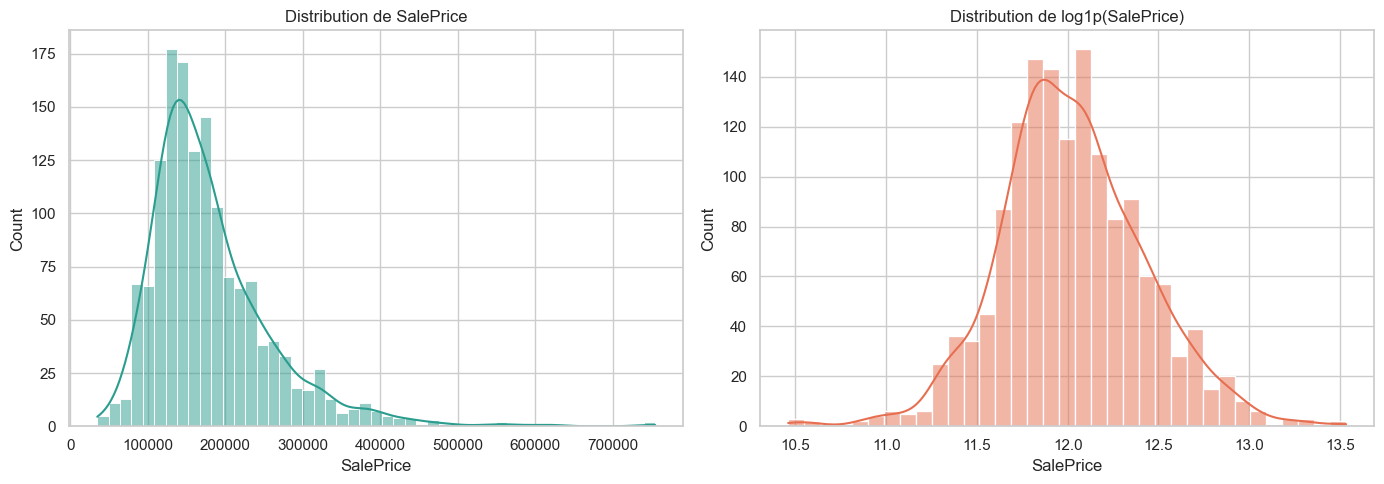

In [3]:
missing_pct = (X.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.head(12).to_frame('missing_%'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y, kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribution de SalePrice')
sns.histplot(y_log, kde=True, ax=axes[1], color='#e76f51')
axes[1].set_title('Distribution de log1p(SalePrice)')
plt.tight_layout()
plt.show()

## 2) Variables logiques

On garde des variables avec un sens métier clair et on ajoute des features dérivées.

In [4]:
logical_numeric = ['OverallQual', 'OverallCond', 'GrLivArea', 'TotalSF', 'TotalBsmtSF', 'GarageArea', 'GarageCars', 'LotArea', 'HouseAge', 'RemodAge', 'TotalBath', 'FullBath', 'TotRmsAbvGrd', 'Fireplaces', 'PorchSF', 'HasGarage', 'HasBasement', 'LotSF_per_room']
logical_categorical = ['Neighborhood', 'ExterQual', 'KitchenQual', 'GarageFinish', 'BsmtQual', 'CentralAir', 'Foundation', 'HeatingQC', 'GarageType', 'PavedDrive', 'Functional', 'MSZoning']
selected_features = logical_numeric + logical_categorical
X_model = X[selected_features].copy()
X_test_model = X_test[selected_features].copy()

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='missing')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, logical_numeric), ('cat', categorical_transformer, logical_categorical)])

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))])

param_distributions = {
    'regressor__n_estimators': [500, 700, 900, 1200],
    'regressor__max_depth': [None, 10, 15, 20, 30],
    'regressor__min_samples_split': [2, 4, 6, 8],
    'regressor__min_samples_leaf': [1, 2, 3, 4],
    'regressor__max_features': ['sqrt', 0.5, 0.7, 1.0],
    'regressor__bootstrap': [True, False]
}

print(f'Nombre de variables: {len(selected_features)}')
print(f'Numériques: {len(logical_numeric)} | Catégorielles: {len(logical_categorical)}')

Nombre de variables: 30
Numériques: 18 | Catégorielles: 12


## 3) Optimisation hyperparamétrique

On optimise le Random Forest directement sur la cible log-transformée pour améliorer le RMSLE.

In [5]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
baseline_scores = -cross_val_score(rf_pipeline, X_model, y_log, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)

search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_model, y_log)

best_model = search.best_estimator_
tuned_scores = -cross_val_score(best_model, X_model, y_log, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)

comparison_df = pd.DataFrame({
    'Modèle': ['Baseline RF', 'RF optimisé'],
    'RMSLE moyen': [baseline_scores.mean(), tuned_scores.mean()],
    'Écart-type': [baseline_scores.std(), tuned_scores.std()]
}).sort_values('RMSLE moyen').reset_index(drop=True)

print('=' * 80)
print('COMPARAISON RANDOM FOREST')
print('=' * 80)
display(comparison_df)
print(f"Meilleurs hyperparamètres: {search.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
COMPARAISON RANDOM FOREST


,Modèle,RMSLE moyen,Écart-type
0,RF optimisé,0.138956,0.018344
1,Baseline RF,0.143340,0.020816


Meilleurs hyperparamètres: {'regressor__n_estimators': 1200, 'regressor__min_samples_split': 4, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 0.5, 'regressor__max_depth': 30, 'regressor__bootstrap': True}


## 4) Soumission finale

Le meilleur modèle est entraîné sur toutes les données puis converti en prix réel avec `expm1`.

In [7]:
best_rmsle = comparison_df.loc[0, 'RMSLE moyen']

print('=' * 80)
print('SOUMISSION V4 GÉNÉRÉE')
print('=' * 80)
print(f'RMSLE retenu: {best_rmsle:.6f}')
print('Fichier: julien_submission_v4.csv')

SOUMISSION V4 GÉNÉRÉE
RMSLE retenu: 0.138956
Fichier: julien_submission_v4.csv


## Résumé

Cette version mise sur un ensemble de variables logique, mais surtout sur un meilleur réglage des hyperparamètres du Random Forest.

Résultat validé:
- RMSLE retenu: 0.138956
- Fichier de soumission: julien_submission_v4.csv